# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Oil Seeds Punjab Dataset](https://www.kaggle.com/datasets/ranamuhammmadusman/oil-seeds-dataset-production-and-yield-analysis)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('oil_seeds_punjab_agricultural_data.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,Year,Crop_Name,Crop_Type,District_Name,Area_Hectares,Production_Tonnes,Yield_Kg_Per_Hectare,Season,Temperature_Celsius_Avg,Rainfall_MM,Irrigation_Requirement_MM,Soil_Type,Market_Price_PKR_Per_Kg,Export_Status,Quality_Grade,Purity_Percent
0,2020,Sunflower,Oilseed,Okara,12500,18750,1500,Spring,32.5,425,250,Sandy Loam,65,Exported,A,96.2
1,2020,Sunflower,Oilseed,Jhang,11200,16240,1450,Spring,31.8,390,260,Loamy,63,Exported,A,95.8
2,2020,Sunflower,Oilseed,Faisalabad,15000,22500,1500,Spring,33.2,410,240,Sandy Loam,65,Exported,A,96.5
3,2020,Sunflower,Oilseed,Sahiwal,8900,11680,1312,Spring,32.1,380,270,Loamy,62,Local Market,B,94.2
4,2020,Sunflower,Oilseed,Gujranwala,7500,9750,1300,Spring,31.5,415,265,Clay Loam,60,Local Market,B,93.8


## last Five row

In [4]:
df.tail()

,Year,Crop_Name,Crop_Type,District_Name,Area_Hectares,Production_Tonnes,Yield_Kg_Per_Hectare,Season,Temperature_Celsius_Avg,Rainfall_MM,Irrigation_Requirement_MM,Soil_Type,Market_Price_PKR_Per_Kg,Export_Status,Quality_Grade,Purity_Percent
73,2025,Rape Seed,Oilseed,Sialkot,5000,4000,800,Winter,19.7,750,150,Sandy Loam,152,Exported,A,99.7
74,2025,Rape Seed,Oilseed,Gujrat,3500,2800,800,Winter,19.4,720,160,Loamy,148,Local Market,B,98.3
75,2025,Gram,Pulse,Okara,11000,10450,950,Winter,21.0,670,120,Sandy Loam,128,Exported,A,98.6
76,2025,Gram,Pulse,Kasur,9400,8930,950,Winter,21.3,680,110,Loamy,129,Exported,A,98.9
77,2025,Gram,Pulse,Sialkot,6700,5695,850,Winter,18.7,730,100,Clay Loam,124,Local Market,B,97.1


## Shape of our dataset

In [5]:
df.shape

(78, 16)

## List out all columns

In [6]:
df.columns

Index(['Year', 'Crop_Name', 'Crop_Type', 'District_Name', 'Area_Hectares',
       'Production_Tonnes', 'Yield_Kg_Per_Hectare', 'Season',
       'Temperature_Celsius_Avg', 'Rainfall_MM', 'Irrigation_Requirement_MM',
       'Soil_Type', 'Market_Price_PKR_Per_Kg', 'Export_Status',
       'Quality_Grade', 'Purity_Percent'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Year                           int64
Crop_Name                     object
Crop_Type                     object
District_Name                 object
Area_Hectares                  int64
Production_Tonnes              int64
Yield_Kg_Per_Hectare           int64
Season                        object
Temperature_Celsius_Avg      float64
Rainfall_MM                    int64
Irrigation_Requirement_MM      int64
Soil_Type                     object
Market_Price_PKR_Per_Kg        int64
Export_Status                 object
Quality_Grade                 object
Purity_Percent               float64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Year                       78 non-null     int64  
 1   Crop_Name                  78 non-null     object 
 2   Crop_Type                  78 non-null     object 
 3   District_Name              78 non-null     object 
 4   Area_Hectares              78 non-null     int64  
 5   Production_Tonnes          78 non-null     int64  
 6   Yield_Kg_Per_Hectare       78 non-null     int64  
 7   Season                     78 non-null     object 
 8   Temperature_Celsius_Avg    78 non-null     float64
 9   Rainfall_MM                78 non-null     int64  
 10  Irrigation_Requirement_MM  78 non-null     int64  
 11  Soil_Type                  78 non-null     object 
 12  Market_Price_PKR_Per_Kg    78 non-null     int64  
 13  Export_Status              78 non-null     object 
 

## Check Null Value

In [9]:
df.isnull().sum()

Year                         0
Crop_Name                    0
Crop_Type                    0
District_Name                0
Area_Hectares                0
Production_Tonnes            0
Yield_Kg_Per_Hectare         0
Season                       0
Temperature_Celsius_Avg      0
Rainfall_MM                  0
Irrigation_Requirement_MM    0
Soil_Type                    0
Market_Price_PKR_Per_Kg      0
Export_Status                0
Quality_Grade                0
Purity_Percent               0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,Year,Area_Hectares,Production_Tonnes,Yield_Kg_Per_Hectare,Temperature_Celsius_Avg,Rainfall_MM,Irrigation_Requirement_MM,Market_Price_PKR_Per_Kg,Purity_Percent
count,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000
mean,2022.500000,12116.666667,18833.205128,1338.615385,28.273077,510.320513,219.615385,90.679487,97.011538
std,1.718879,6750.688597,15350.553334,441.423825,7.283047,135.743120,77.420966,27.957061,1.335332
min,2020.000000,2100.000000,1680.000000,800.000000,17.200000,280.000000,100.000000,44.000000,93.800000
25%,2021.000000,7575.000000,7505.000000,950.000000,19.800000,402.500000,150.000000,68.500000,96.200000
50%,2022.500000,10900.000000,13650.000000,1300.000000,32.450000,470.000000,250.000000,86.000000,97.100000
75%,2024.000000,15575.000000,26625.000000,1500.000000,34.100000,650.000000,270.000000,114.250000,98.000000
max,2025.000000,29500.000000,59000.000000,2000.000000,36.700000,750.000000,320.000000,152.000000,99.700000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

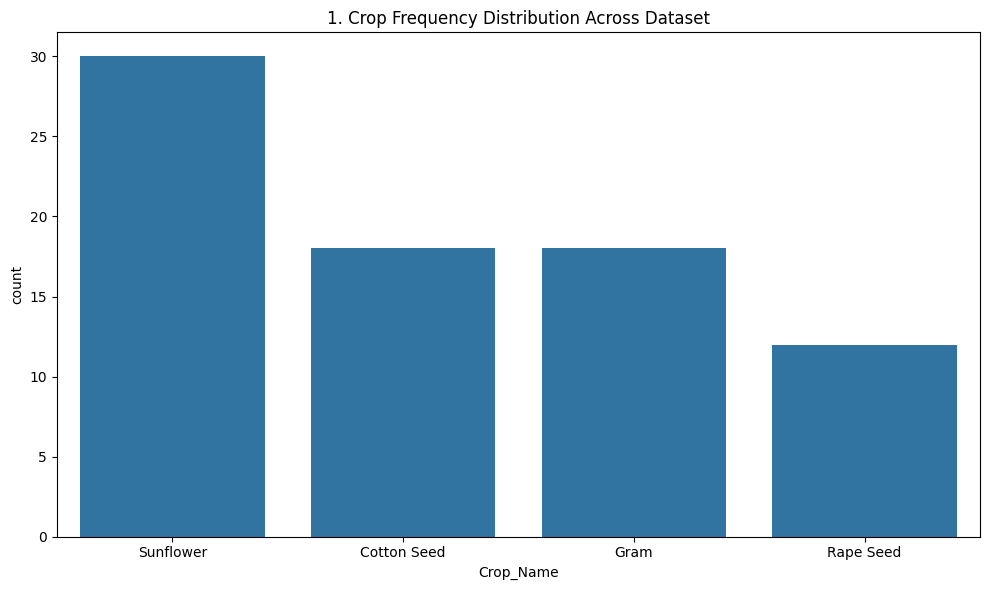

In [13]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Crop_Name', order=df['Crop_Name'].value_counts().index)
plt.title(f'{plot_no}. Crop Frequency Distribution Across Dataset')
show_fig()
plot_no += 1

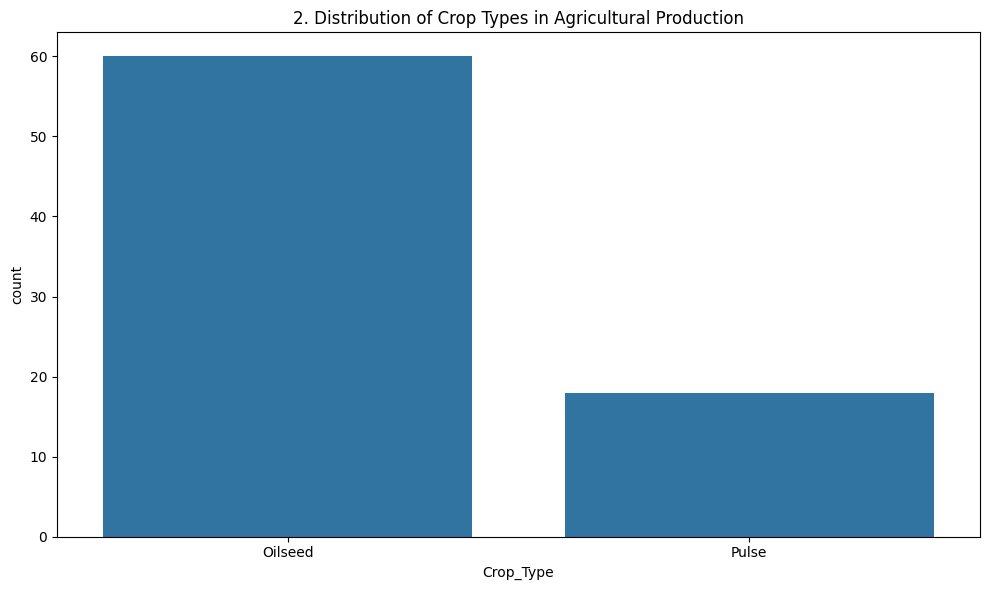

In [14]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Crop_Type', order=df['Crop_Type'].value_counts().index)
plt.title(f'{plot_no}. Distribution of Crop Types in Agricultural Production')
show_fig()
plot_no += 1

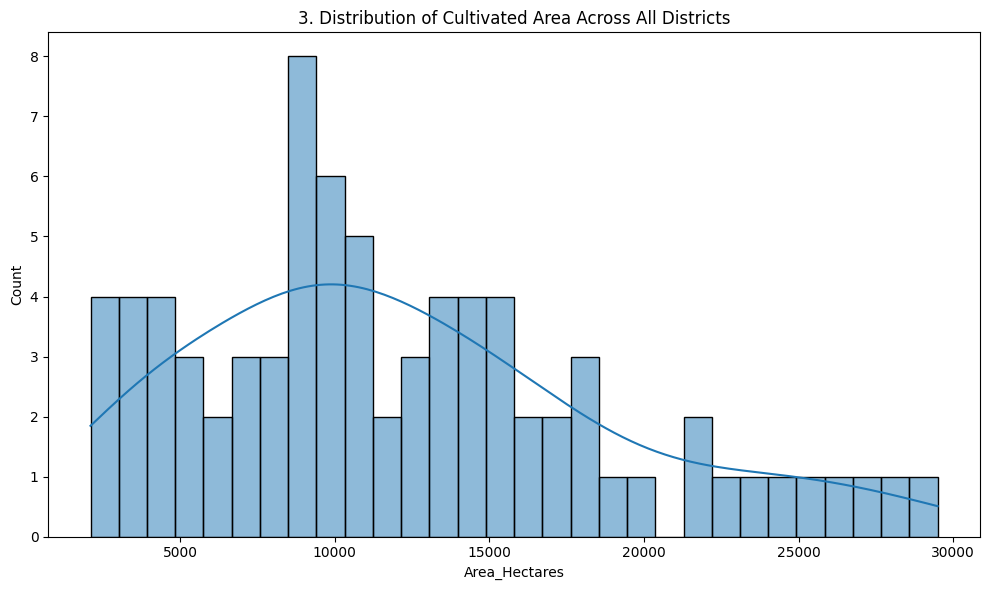

In [15]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Area_Hectares'], bins=30, kde=True)
plt.title(f'{plot_no}. Distribution of Cultivated Area Across All Districts')
show_fig()
plot_no += 1

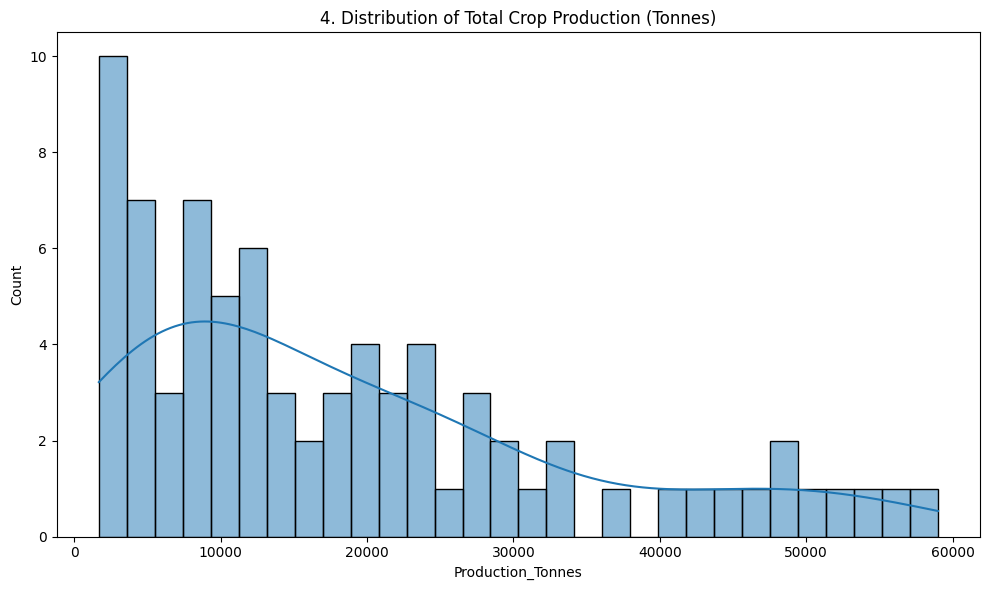

In [16]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Production_Tonnes'], bins=30, kde=True)
plt.title(f'{plot_no}. Distribution of Total Crop Production (Tonnes)')
show_fig()
plot_no += 1

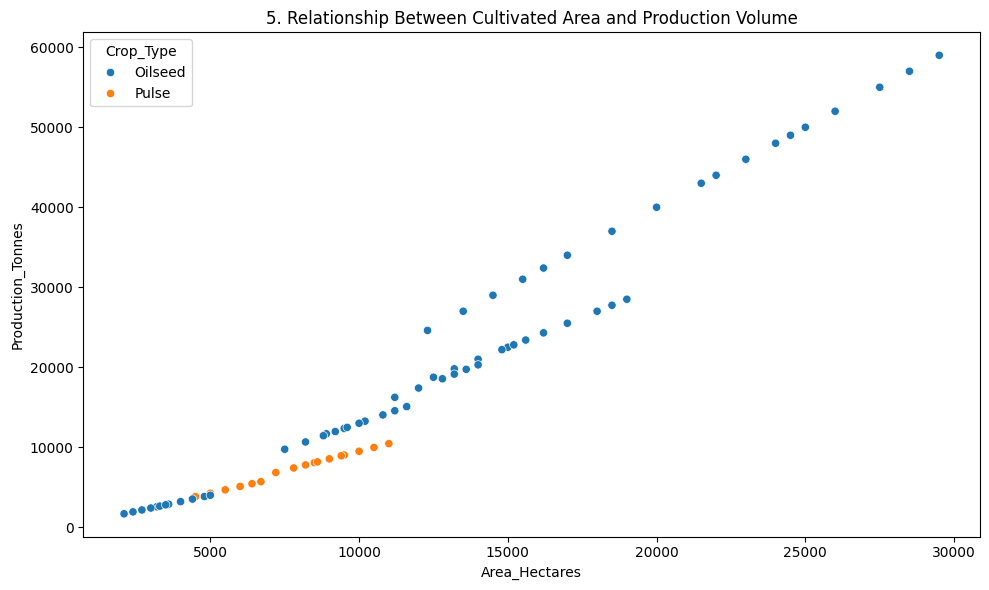

In [17]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Area_Hectares', y='Production_Tonnes', hue='Crop_Type')
plt.title(f'{plot_no}. Relationship Between Cultivated Area and Production Volume')
show_fig()
plot_no += 1

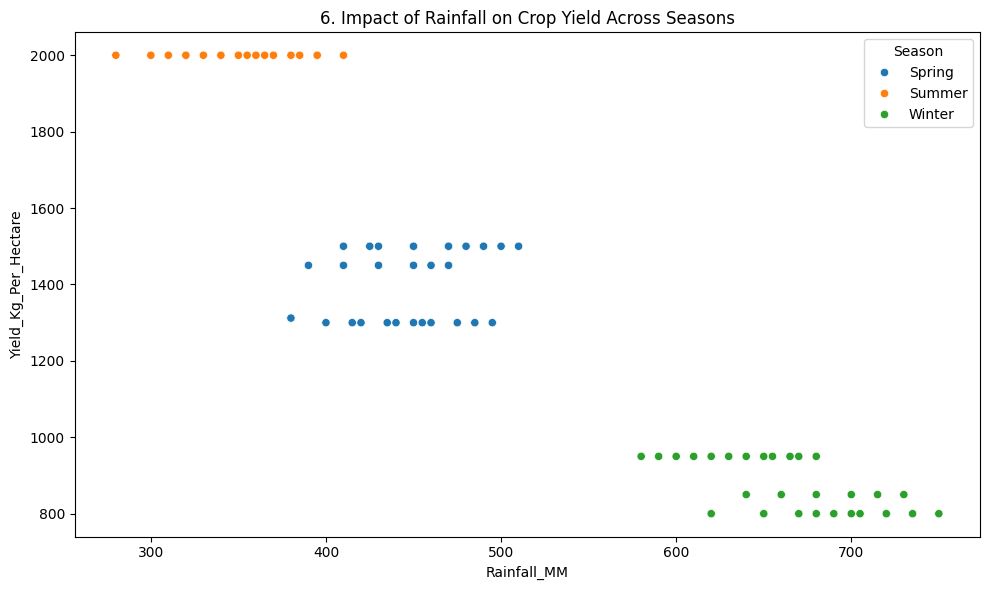

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Rainfall_MM', y='Yield_Kg_Per_Hectare', hue='Season')
plt.title(f'{plot_no}. Impact of Rainfall on Crop Yield Across Seasons')
show_fig()
plot_no += 1

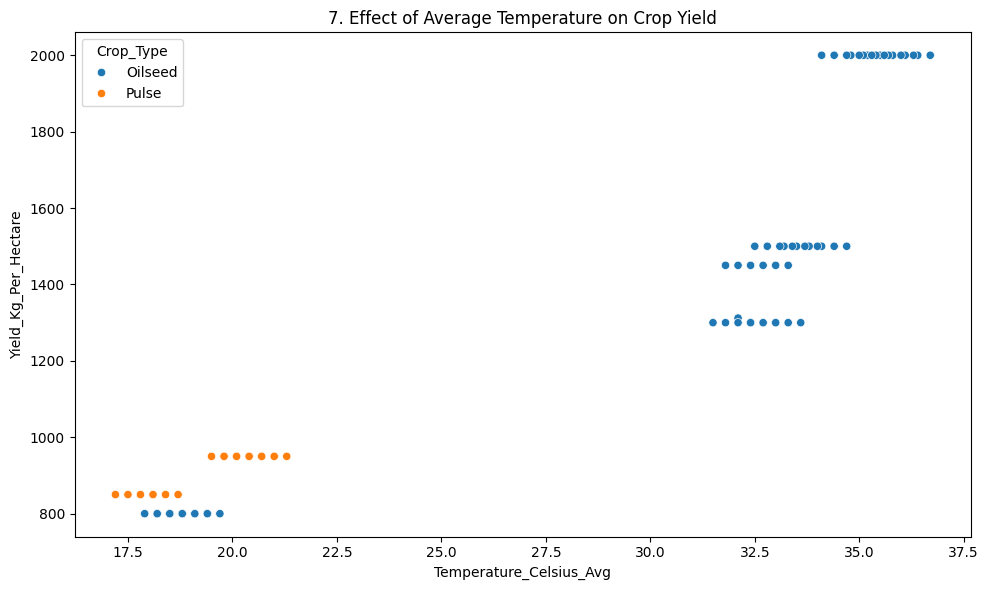

In [19]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Temperature_Celsius_Avg', y='Yield_Kg_Per_Hectare', hue='Crop_Type')
plt.title(f'{plot_no}. Effect of Average Temperature on Crop Yield')
show_fig()
plot_no += 1

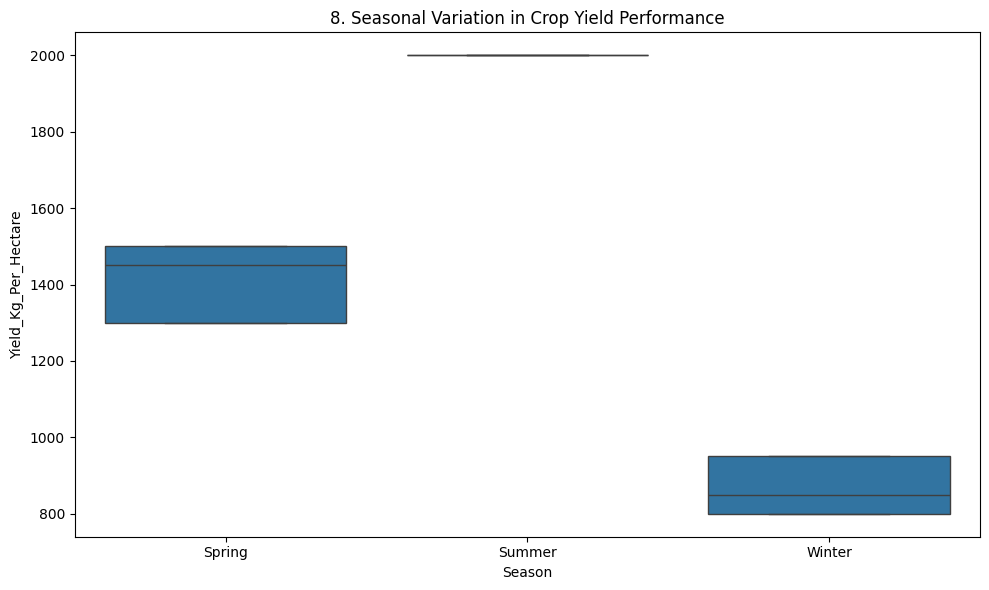

In [20]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Season', y='Yield_Kg_Per_Hectare')
plt.title(f'{plot_no}. Seasonal Variation in Crop Yield Performance')
show_fig()
plot_no += 1

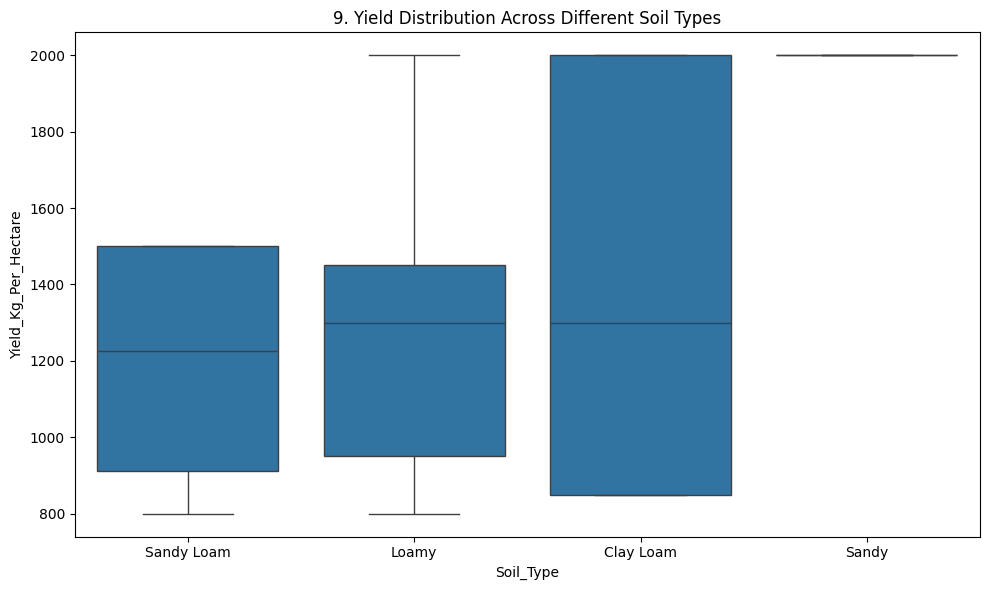

In [21]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Soil_Type', y='Yield_Kg_Per_Hectare')
plt.title(f'{plot_no}. Yield Distribution Across Different Soil Types')
show_fig()
plot_no += 1

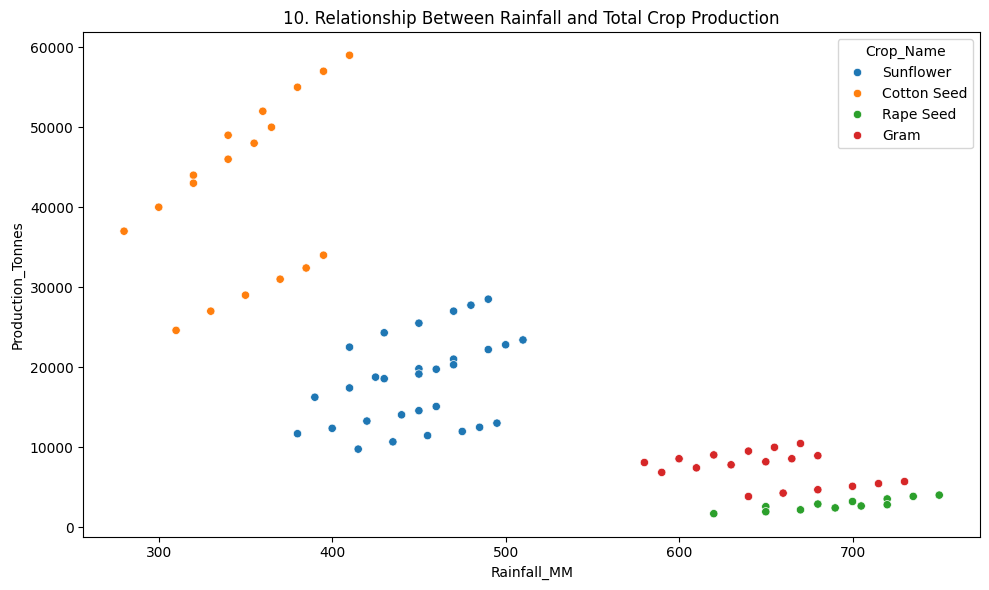

In [22]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Rainfall_MM', y='Production_Tonnes', hue='Crop_Name')
plt.title(f'{plot_no}. Relationship Between Rainfall and Total Crop Production')
show_fig()
plot_no += 1

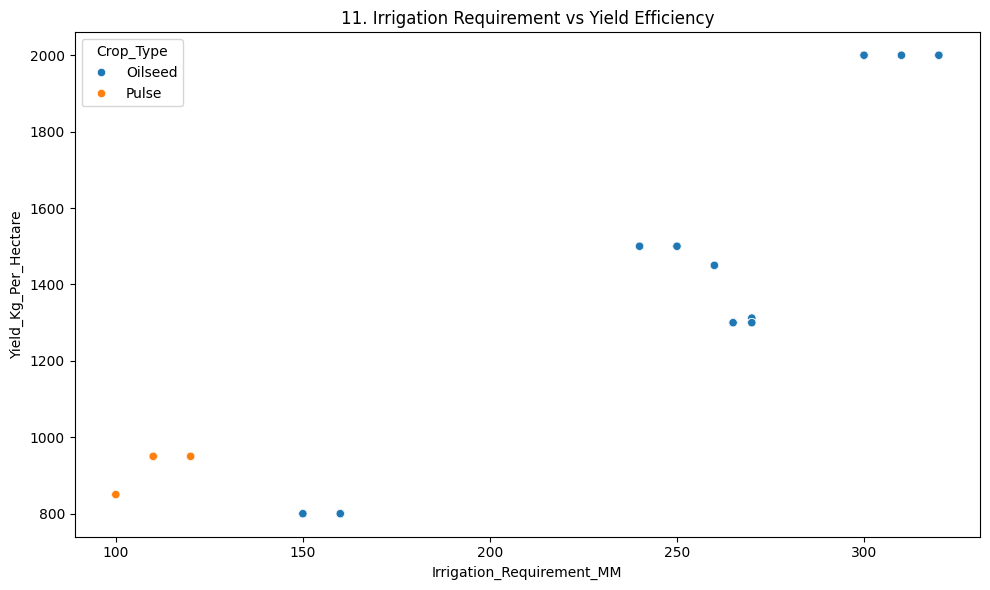

In [23]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Irrigation_Requirement_MM', y='Yield_Kg_Per_Hectare', hue='Crop_Type')
plt.title(f'{plot_no}. Irrigation Requirement vs Yield Efficiency')
show_fig()
plot_no += 1

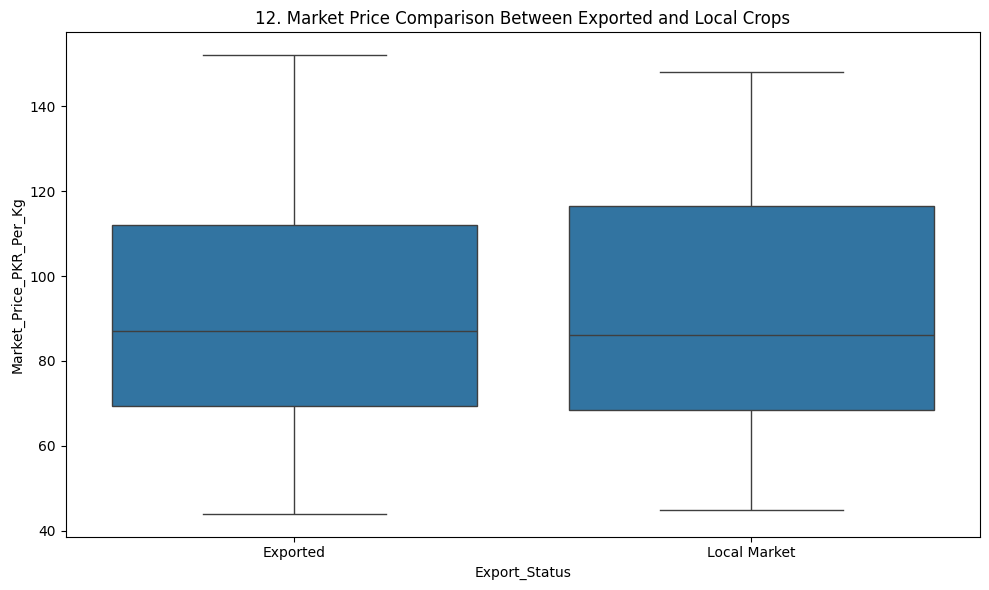

In [24]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Export_Status', y='Market_Price_PKR_Per_Kg')
plt.title(f'{plot_no}. Market Price Comparison Between Exported and Local Crops')
show_fig()
plot_no += 1

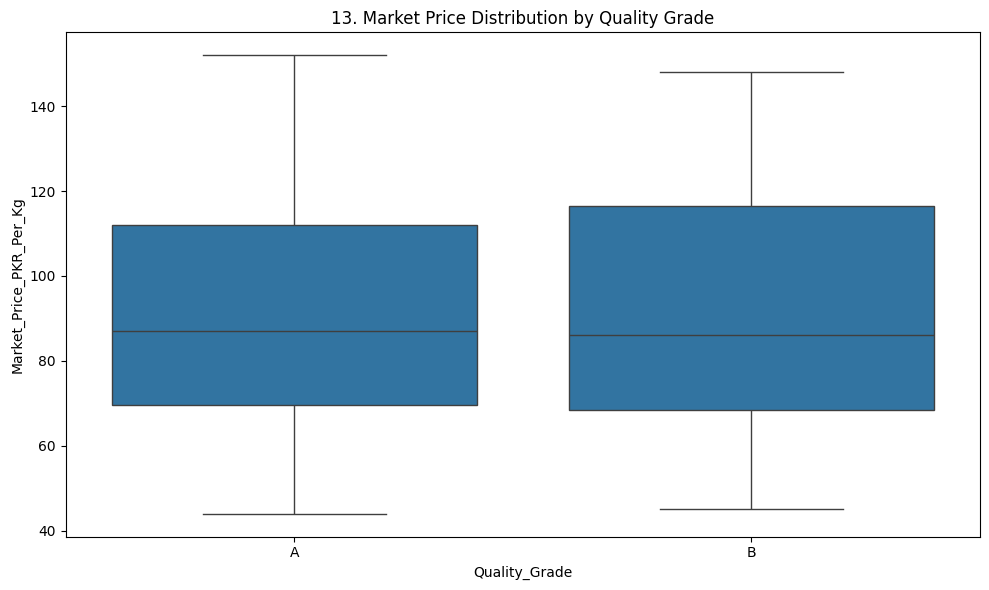

In [25]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Quality_Grade', y='Market_Price_PKR_Per_Kg')
plt.title(f'{plot_no}. Market Price Distribution by Quality Grade')
show_fig()
plot_no += 1

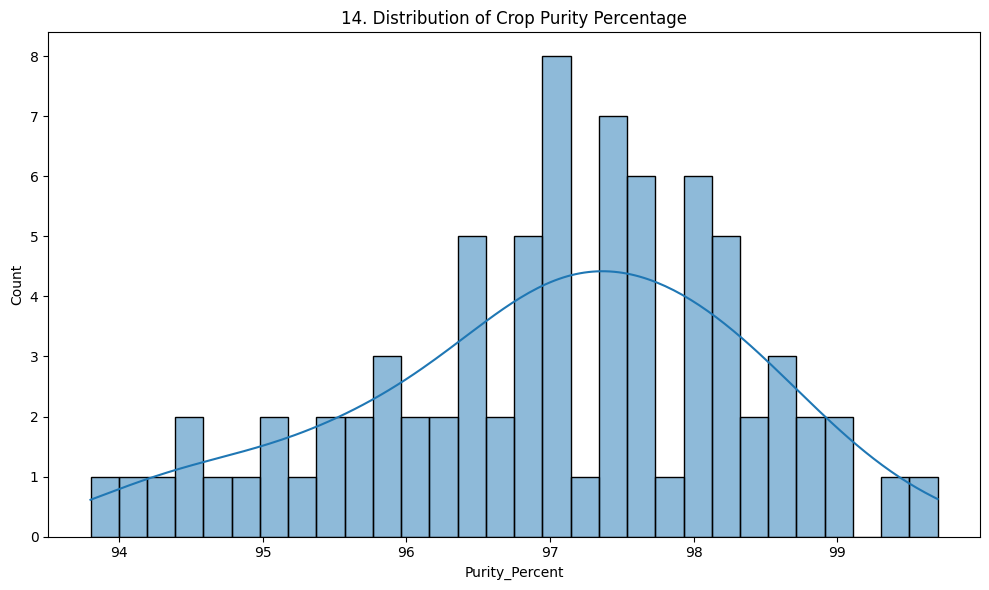

In [26]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Purity_Percent'], bins=30, kde=True)
plt.title(f'{plot_no}. Distribution of Crop Purity Percentage')
show_fig()
plot_no += 1

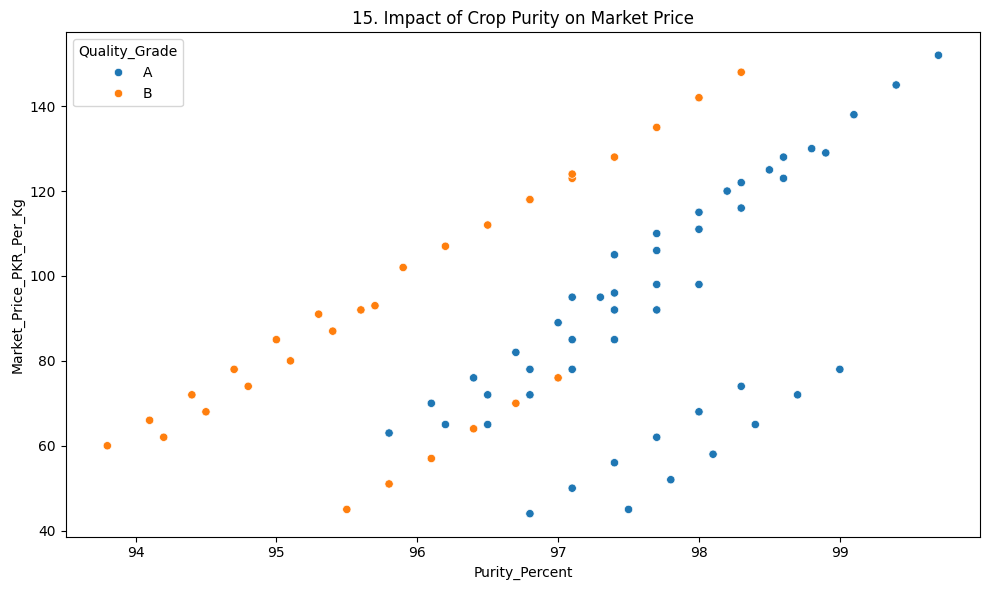

In [27]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Purity_Percent', y='Market_Price_PKR_Per_Kg', hue='Quality_Grade')
plt.title(f'{plot_no}. Impact of Crop Purity on Market Price')
show_fig()
plot_no += 1

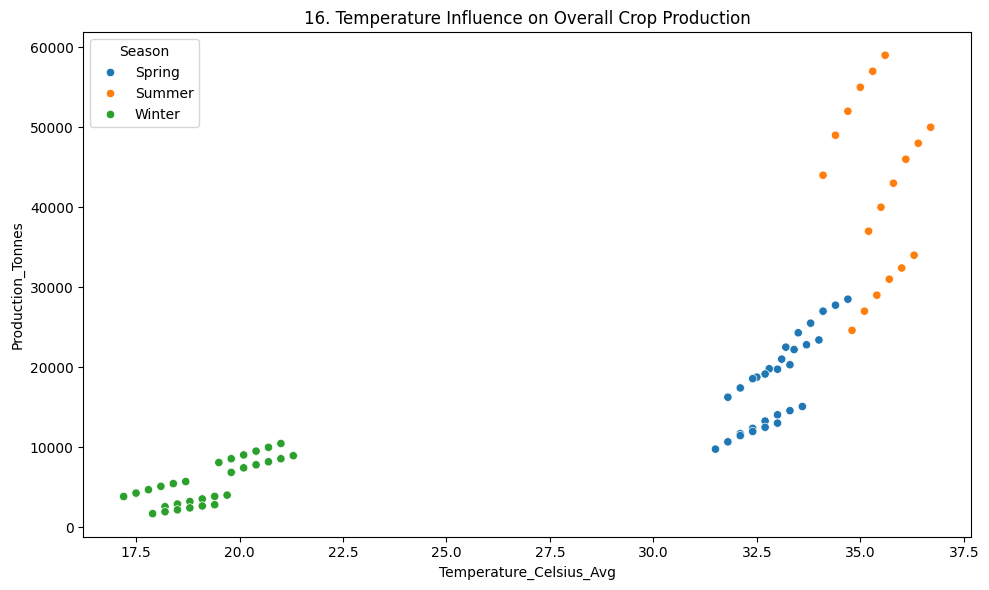

In [28]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Temperature_Celsius_Avg', y='Production_Tonnes', hue='Season')
plt.title(f'{plot_no}. Temperature Influence on Overall Crop Production')
show_fig()
plot_no += 1

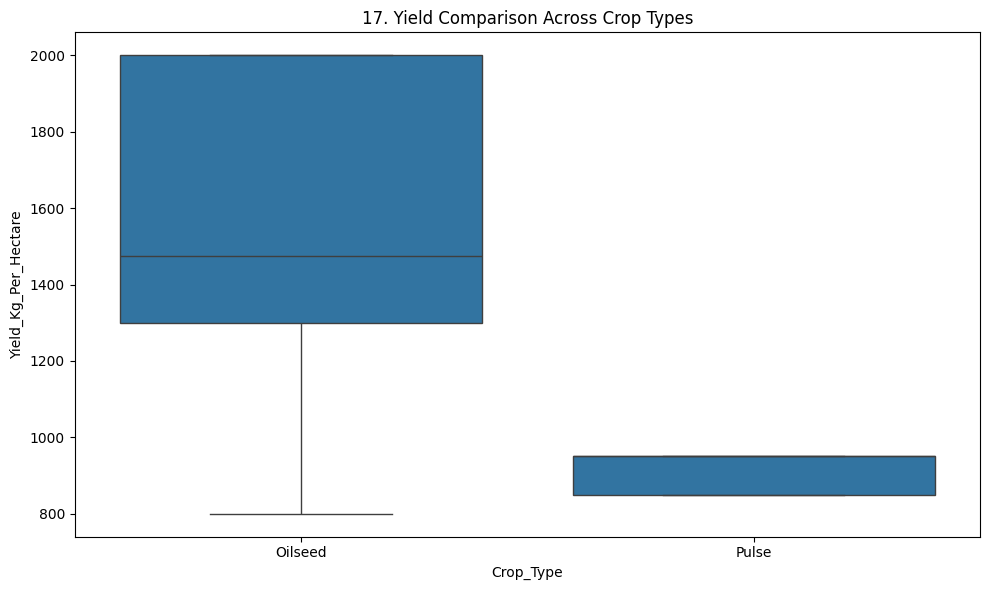

In [29]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Crop_Type', y='Yield_Kg_Per_Hectare')
plt.title(f'{plot_no}. Yield Comparison Across Crop Types')
show_fig()
plot_no += 1

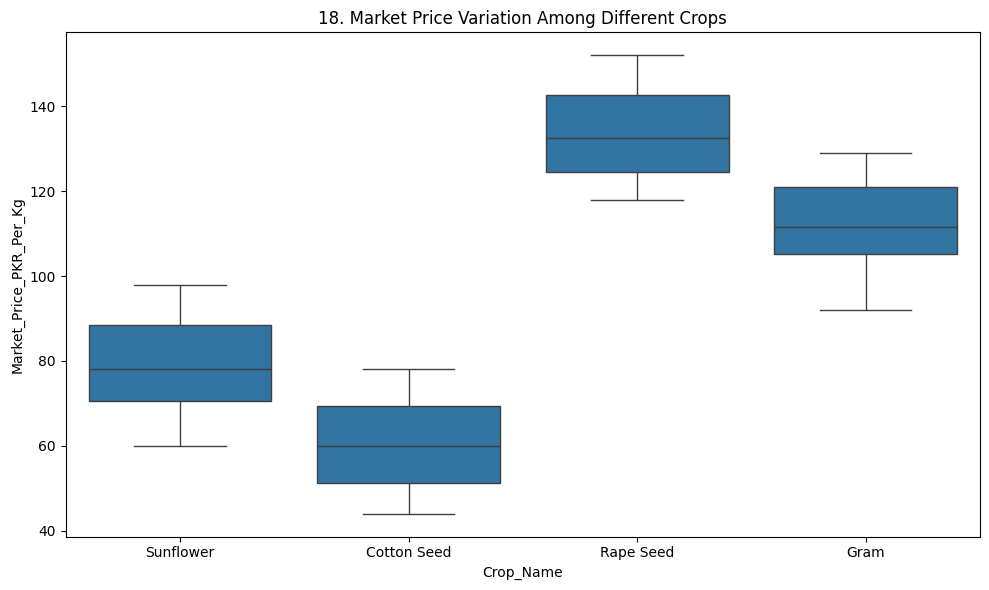

In [30]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Crop_Name', y='Market_Price_PKR_Per_Kg')
plt.title(f'{plot_no}. Market Price Variation Among Different Crops')
show_fig()
plot_no += 1

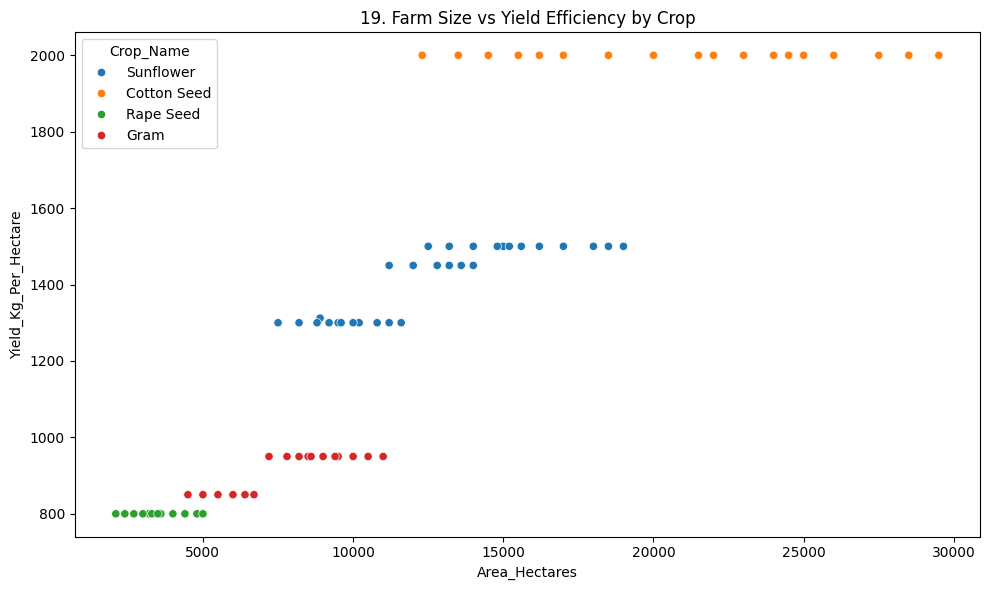

In [31]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Area_Hectares', y='Yield_Kg_Per_Hectare', hue='Crop_Name')
plt.title(f'{plot_no}. Farm Size vs Yield Efficiency by Crop')
show_fig()
plot_no += 1

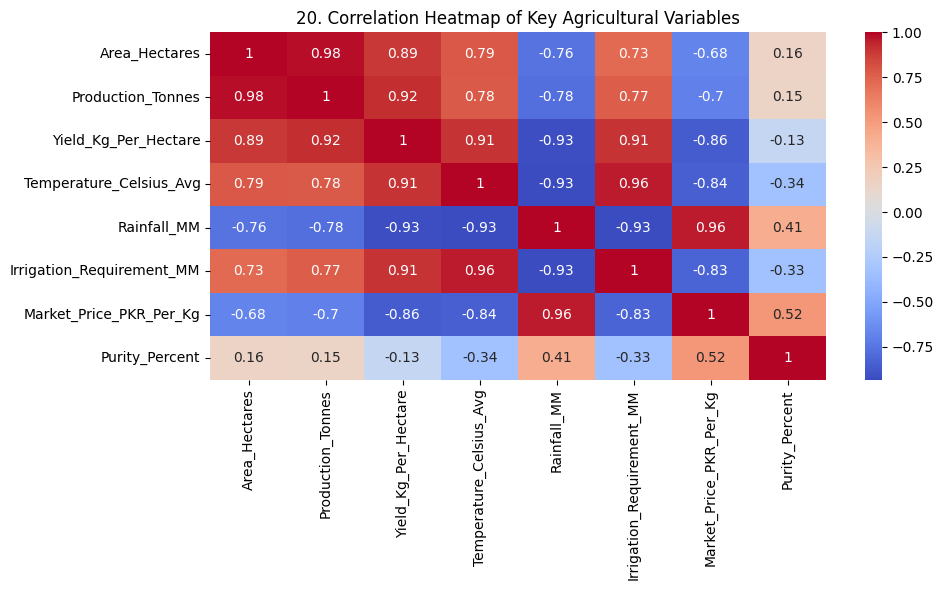

In [32]:
fig = plt.figure(figsize=(10,6))
corr = df[['Area_Hectares','Production_Tonnes','Yield_Kg_Per_Hectare','Temperature_Celsius_Avg','Rainfall_MM','Irrigation_Requirement_MM','Market_Price_PKR_Per_Kg','Purity_Percent']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Key Agricultural Variables')
show_fig()
plot_no += 1

# Model Training

## Convert categorical columns into numeric using one-hot encoding

In [33]:
df_encoded = pd.get_dummies(df, drop_first=True)

## Select features and target variable

In [34]:
X = df_encoded.drop("Production_Tonnes", axis=1)
y = df_encoded["Production_Tonnes"]

## Split dataset into training and testing sets

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Apply feature scaling for better model performance

In [36]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Train supervised machine learning model

In [37]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Generate predictions

In [38]:
y_pred = model.predict(X_test)

## Calculate model accuracy using R² score

In [39]:
score = r2_score(y_test, y_pred)
print("Model R2 Score:", score)

Model R2 Score: 0.9997762085666118


## Plot Actual vs Predicted values

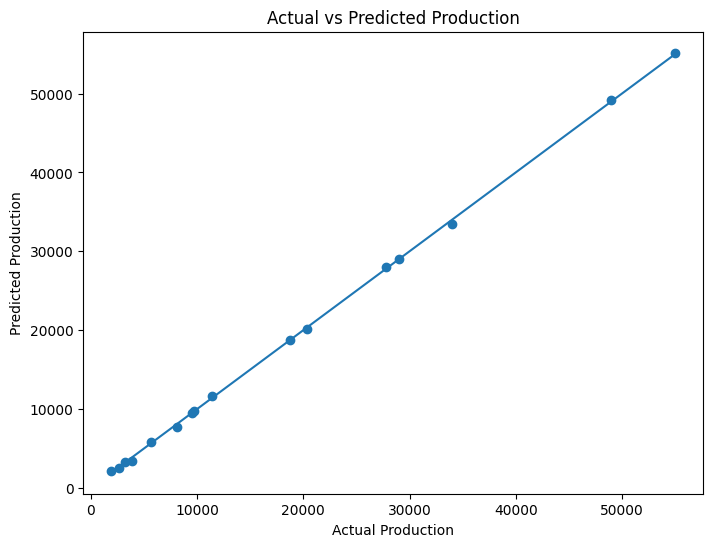

In [40]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Production")
plt.ylabel("Predicted Production")
plt.title("Actual vs Predicted Production")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.show()